In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

In [2]:
file_pattern = "*.csv"
data_path = os.fspath("data/mar11")

data_files = glob.glob(file_pattern, root_dir=data_path)

print(f"Found {len(data_files)} data files")

Found 1 data files


In [3]:
df_list = []

for file_name in data_files:
    file = os.path.join(data_path, file_name)
    print(file_name)
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

data_raw = pd.concat(df_list, ignore_index=True)
display(data_raw)
display(data_raw.dtypes)

vertical_force_data_20260311_13-14-35.csv


,Time (s.ms),Force_gauge (N),Linear_position (mm),strain_0.0800m (µε),strain_2.2922m (µε),strain_0.0800m (µε).1,strain_0.0807m (µε),strain_0.0813m (µε),strain_0.0820m (µε),strain_0.0826m (µε),...,strain_2.2894m (µε),strain_2.2900m (µε),strain_2.2906m (µε),strain_2.2913m (µε),strain_2.2919m (µε),strain_2.2926m (µε),strain_2.2933m (µε),strain_2.2939m (µε),strain_2.2945m (µε),strain_2.2952m (µε)
0,40.627,-0.02,-0.100342,0.2,6.80000,0.2,3.1,-3.3,2.0,-9.9,...,-0.200000,5.100000,-1.500000,-9.400000,2.100000,-1.200000,1.400000,8.900000,2.700000,6.80000
1,40.899,0.00,-0.075195,-2.9,3.90000,-2.9,0.5,-1.8,3.4,-11.6,...,-5.200000,-2.800000,7.100000,2.200000,-0.100000,-7.600000,-3.900000,0.700000,5.800000,3.90000
2,41.171,0.02,-0.049805,1.2,4.90000,1.2,4.9,2.3,0.0,-10.3,...,0.800000,9.200000,8.500000,-4.800000,-13.400000,-8.400000,1.100000,2.200000,4.000000,4.90000
3,41.444,0.00,-0.024170,-3.7,1.30000,-3.7,-2.9,-3.5,-8.4,-5.0,...,7.300000,1.400000,0.400000,-0.600000,-2.300000,-17.000000,-6.700000,18.700000,11.700000,1.30000
4,41.715,0.00,0.001709,3.0,8.20000,3.0,6.2,-2.7,-1.4,-4.4,...,9.300000,7.600000,5.700000,-7.200000,-15.800000,-13.900000,6.400000,16.800000,10.900000,8.20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,23.165,0.62,7.706299,7.8,10029.80000,7.8,0.0,-5.1,-5.7,-15.1,...,11891.699609,11850.600000,11780.000391,11631.499609,11416.899610,11196.699609,10958.300000,10718.099609,10399.400000,10029.80000
378,23.438,0.62,7.706055,6.1,10038.89961,6.1,0.6,-11.0,-2.2,-4.2,...,11902.800195,11851.199609,11798.899805,11627.699805,11433.700391,11206.100000,10956.700391,10708.000000,10393.300391,10038.89961
379,23.709,0.64,7.706299,0.8,10026.80000,0.8,-0.4,-4.8,-2.1,-6.6,...,11898.699609,11860.100000,11781.800195,11624.800391,11425.800000,11192.399805,10957.300000,10705.000000,10389.600195,10026.80000
380,23.981,0.60,7.706299,8.9,10024.30000,8.9,3.0,-1.6,1.0,-1.5,...,11898.199609,11857.500391,11789.600000,11631.300391,11422.500196,11196.600000,10947.300000,10707.099609,10392.999609,10024.30000


Time (s.ms)             float64
Force_gauge (N)         float64
Linear_position (mm)    float64
strain_0.0800m (µε)     float64
strain_2.2922m (µε)     float64
                         ...   
strain_2.2926m (µε)     float64
strain_2.2933m (µε)     float64
strain_2.2939m (µε)     float64
strain_2.2945m (µε)     float64
strain_2.2952m (µε)     float64
Length: 3414, dtype: object

In [4]:
data = data_raw.loc[:, ~data_raw.columns.str.contains(r"\.\d+$")]

strain_cols = [col for col in data.columns if col.startswith("strain")]
other_cols = [col for col in data.columns if col not in strain_cols]

x_axis_raw = np.array([float(re.search(r"strain_(.*)m", x).group(1)) for x in strain_cols])
sorted_idx = np.argsort(x_axis_raw)
x_axis = np.sort(x_axis_raw)
sorted_strain_cols = [strain_cols[i] for i in sorted_idx]
data = data[other_cols + sorted_strain_cols]
strain_positions = [data.columns.get_loc(col) for col in sorted_strain_cols]
strain_values = data[sorted_strain_cols].values.astype(float)

data[sorted_strain_cols] = strain_values
display(data)

,Time (s.ms),Force_gauge (N),Linear_position (mm),strain_0.0800m (µε),strain_0.0807m (µε),strain_0.0813m (µε),strain_0.0820m (µε),strain_0.0826m (µε),strain_0.0833m (µε),strain_0.0839m (µε),...,strain_2.2900m (µε),strain_2.2906m (µε),strain_2.2913m (µε),strain_2.2919m (µε),strain_2.2922m (µε),strain_2.2926m (µε),strain_2.2933m (µε),strain_2.2939m (µε),strain_2.2945m (µε),strain_2.2952m (µε)
0,40.627,-0.02,-0.100342,0.2,3.1,-3.3,2.0,-9.9,-9.5,1.2,...,5.100000,-1.500000,-9.400000,2.100000,6.80000,-1.200000,1.400000,8.900000,2.700000,6.80000
1,40.899,0.00,-0.075195,-2.9,0.5,-1.8,3.4,-11.6,-5.9,-1.6,...,-2.800000,7.100000,2.200000,-0.100000,3.90000,-7.600000,-3.900000,0.700000,5.800000,3.90000
2,41.171,0.02,-0.049805,1.2,4.9,2.3,0.0,-10.3,-10.8,-0.3,...,9.200000,8.500000,-4.800000,-13.400000,4.90000,-8.400000,1.100000,2.200000,4.000000,4.90000
3,41.444,0.00,-0.024170,-3.7,-2.9,-3.5,-8.4,-5.0,-6.6,-2.2,...,1.400000,0.400000,-0.600000,-2.300000,1.30000,-17.000000,-6.700000,18.700000,11.700000,1.30000
4,41.715,0.00,0.001709,3.0,6.2,-2.7,-1.4,-4.4,-6.4,-3.1,...,7.600000,5.700000,-7.200000,-15.800000,8.20000,-13.900000,6.400000,16.800000,10.900000,8.20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,23.165,0.62,7.706299,7.8,0.0,-5.1,-5.7,-15.1,-0.9,2.6,...,11850.600000,11780.000391,11631.499609,11416.899610,10029.80000,11196.699609,10958.300000,10718.099609,10399.400000,10029.80000
378,23.438,0.62,7.706055,6.1,0.6,-11.0,-2.2,-4.2,-9.6,-6.0,...,11851.199609,11798.899805,11627.699805,11433.700391,10038.89961,11206.100000,10956.700391,10708.000000,10393.300391,10038.89961
379,23.709,0.64,7.706299,0.8,-0.4,-4.8,-2.1,-6.6,-14.0,-3.1,...,11860.100000,11781.800195,11624.800391,11425.800000,10026.80000,11192.399805,10957.300000,10705.000000,10389.600195,10026.80000
380,23.981,0.60,7.706299,8.9,3.0,-1.6,1.0,-1.5,-13.0,-9.0,...,11857.500391,11789.600000,11631.300391,11422.500196,10024.30000,11196.600000,10947.300000,10707.099609,10392.999609,10024.30000


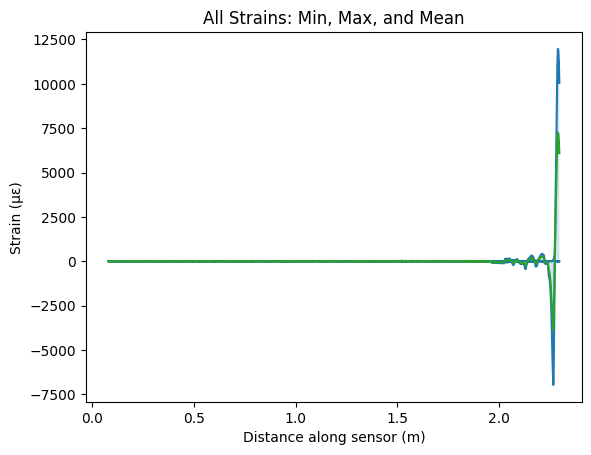

In [5]:
upper_bound = data[sorted_strain_cols].max()
lower_bound = data[sorted_strain_cols].min()
mean_line = data[sorted_strain_cols].mean()

fig, ax = plt.subplots()
ax.plot(x_axis,upper_bound,color='tab:blue')
ax.plot(x_axis,lower_bound,color='tab:blue')
ax.plot(x_axis,mean_line,color='tab:green')
ax.fill_between(x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("All Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
plt.show()

,strain_2.2250m (µε),strain_2.2257m (µε),strain_2.2263m (µε),strain_2.2269m (µε),strain_2.2276m (µε),strain_2.2283m (µε),strain_2.2289m (µε),strain_2.2295m (µε),strain_2.2302m (µε),strain_2.2308m (µε),...,strain_2.2900m (µε),strain_2.2906m (µε),strain_2.2913m (µε),strain_2.2919m (µε),strain_2.2922m (µε),strain_2.2926m (µε),strain_2.2933m (µε),strain_2.2939m (µε),strain_2.2945m (µε),strain_2.2952m (µε)
0,7.6,-5.8,-3.900000,-9.700001,-2.700000,4.800000,4.500000,4.6,-7.900000,-0.900000,...,5.100000,-1.500000,-9.400000,2.100000,6.80000,-1.200000,1.400000,8.900000,2.700000,6.80000
1,-1.4,0.2,-4.800000,-22.400001,-12.200000,2.700000,2.700000,1.2,-1.000000,-4.800000,...,-2.800000,7.100000,2.200000,-0.100000,3.90000,-7.600000,-3.900000,0.700000,5.800000,3.90000
2,0.8,4.0,5.300000,-8.300001,-6.900000,-6.000000,5.200000,-2.4,-4.900000,3.800000,...,9.200000,8.500000,-4.800000,-13.400000,4.90000,-8.400000,1.100000,2.200000,4.000000,4.90000
3,1.3,0.9,-1.900000,-3.100000,5.300000,3.800000,5.300000,-5.8,-5.000000,-0.600000,...,1.400000,0.400000,-0.600000,-2.300000,1.30000,-17.000000,-6.700000,18.700000,11.700000,1.30000
4,-7.9,3.8,6.200000,-8.700001,-6.100000,-2.500000,-2.600000,-6.8,-4.400000,3.500000,...,7.600000,5.700000,-7.200000,-15.800000,8.20000,-13.900000,6.400000,16.800000,10.900000,8.20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,-7.2,-9.2,-7.900000,-24.400001,-21.400000,-20.900000,-18.400001,-19.5,-23.700000,-28.600000,...,11850.600000,11780.000391,11631.499609,11416.899610,10029.80000,11196.699609,10958.300000,10718.099609,10399.400000,10029.80000
378,-14.8,-11.6,-15.800000,-27.000001,-23.600000,-20.299999,-18.600000,-21.0,-28.700000,-33.399999,...,11851.199609,11798.899805,11627.699805,11433.700391,10038.89961,11206.100000,10956.700391,10708.000000,10393.300391,10038.89961
379,-11.2,-13.8,-19.300000,-29.000001,-18.900000,-17.000000,-11.900000,-11.7,-17.200000,-38.200000,...,11860.100000,11781.800195,11624.800391,11425.800000,10026.80000,11192.399805,10957.300000,10705.000000,10389.600195,10026.80000
380,-8.8,-14.4,-18.400000,-28.700001,-17.500000,-11.100000,-5.400000,-23.3,-31.500001,-37.899999,...,11857.500391,11789.600000,11631.300391,11422.500196,10024.30000,11196.600000,10947.300000,10707.099609,10392.999609,10024.30000


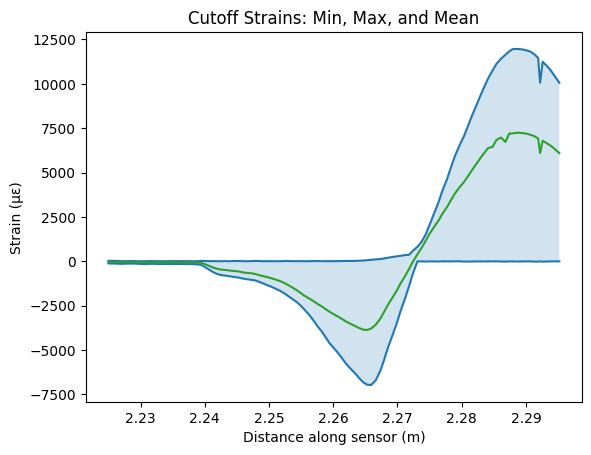

In [6]:
start_location = 2.225
cutoff_idx = (np.abs(x_axis - start_location)).argmin()
cutoff_strain = data[sorted_strain_cols].iloc[:,cutoff_idx:]
cutoff_x_axis = x_axis[cutoff_idx:]

upper_bound = cutoff_strain.max()
lower_bound = cutoff_strain.min()
mean_line = cutoff_strain.mean()

fig, ax = plt.subplots()
ax.plot(cutoff_x_axis,upper_bound,color='tab:blue')
ax.plot(cutoff_x_axis,lower_bound,color='tab:blue')
ax.plot(cutoff_x_axis,mean_line,color='tab:green')
ax.fill_between(cutoff_x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("Cutoff Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
display(cutoff_strain)
plt.show()

382 382


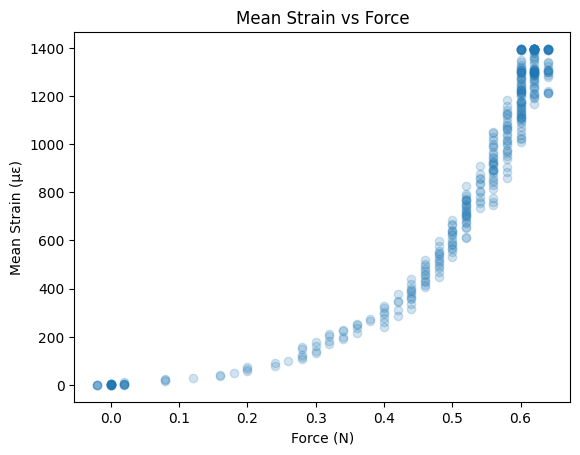

In [7]:
x_data = data["Force_gauge (N)"].values
y_data = cutoff_strain.mean(axis=1).values
print(len(x_data), len(y_data))
plt.scatter(x_data, y_data, color='tab:blue', alpha=0.2)
plt.xlabel("Force (N)")
plt.ylabel("Mean Strain (με)")
plt.title("Mean Strain vs Force")
plt.show()

382 382


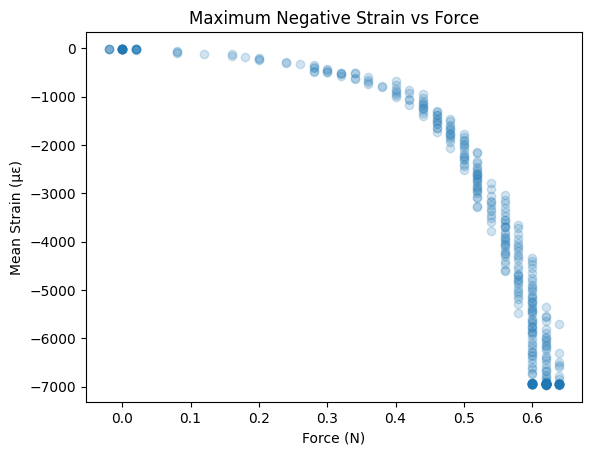

In [8]:
x_data = data["Force_gauge (N)"].values
y_data = cutoff_strain.min(axis=1).values
print(len(x_data), len(y_data))
plt.scatter(x_data, y_data, color='tab:blue', alpha=0.2)
plt.xlabel("Force (N)")
plt.ylabel("Mean Strain (με)")
plt.title("Maximum Negative Strain vs Force")
plt.show()

382 382


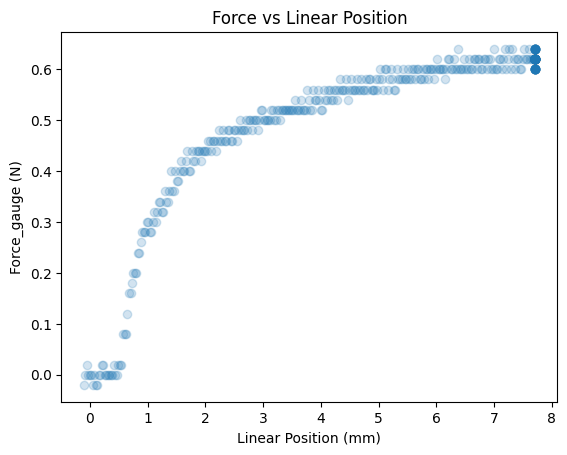

In [9]:
x_data = data["Linear_position (mm)"].values
y_data = data["Force_gauge (N)"].values
print(len(x_data), len(y_data))
plt.scatter(x_data, y_data, color='tab:blue', alpha=0.2)
plt.xlabel("Linear Position (mm)")
plt.ylabel("Force_gauge (N)")
plt.title("Force vs Linear Position")
plt.show()

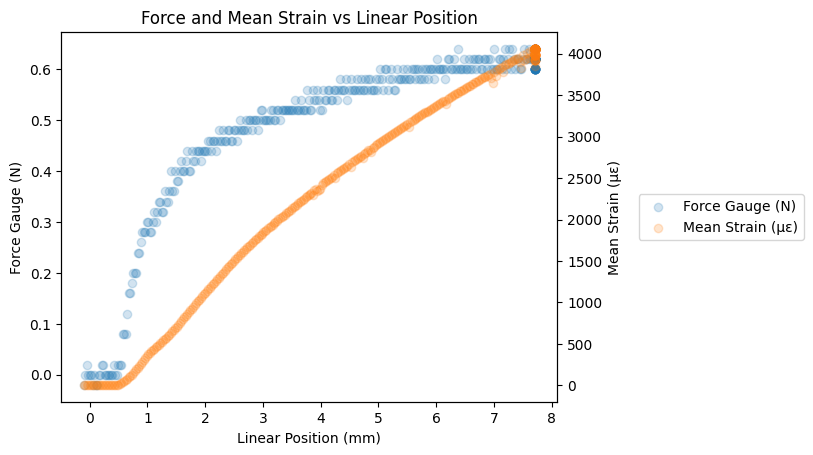

In [10]:
x_data1 = data["Linear_position (mm)"].values
y_data1 = data["Force_gauge (N)"].values
y_data2 = np.abs(cutoff_strain).mean(axis=1).values
fig, ax1 = plt.subplots()

# Left y-axis
ax1.scatter(x_data1, y_data1, label="Force Gauge (N)", color='tab:blue', alpha=0.2)
ax1.set_xlabel("Linear Position (mm)")
ax1.set_ylabel("Force Gauge (N)")
ax1.tick_params(axis='y')

# Right y-axis
ax2 = ax1.twinx()
ax2.scatter(x_data1, y_data2, label="Mean Strain (με)", color='tab:orange', alpha=0.2)
ax2.set_ylabel("Mean Strain (με)")
ax2.tick_params(axis='y')

lines = [ax1.collections[0], ax2.collections[0]]
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="center left", bbox_to_anchor=(1.15, 0.5))
plt.title("Force and Mean Strain vs Linear Position")

plt.show()